### Introduction to Dask and Job Queue Management

The next cell installs the `dask-jobqueue` and `graphviz` Python packages. The `dask-jobqueue` package is used to manage and scale Dask clusters on job queuing systems, while `graphviz` is used for visualizing computational graphs. The `--upgrade` flag ensures that the latest versions of these packages are installed.

In [1]:
%pip install dask-jobqueue graphviz --upgrade


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Setting Up the Dask Cluster

The next cell sets up a Dask cluster using the `SGECluster` class from the `dask_jobqueue` package. It specifies the cluster configuration, including the number of cores, memory, and job queue. Additionally, it uses a job script prologue to load necessary environment settings. The cluster is then scaled to 20 workers, and a Dask `Client` is created to interact with the cluster.

In [2]:
from dask_jobqueue import SGECluster

job_script_prologue = [
    "source /afs/crc.nd.edu/user/a/akuehlka/.bashrc",
    "source /afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/bin/activate"
]

cluster = SGECluster(
    name = "dask-worker",
    cores = 1,
    processes = 1,
    memory = "2GB",
    local_directory = "/tmp",
    queue = "long",
    job_script_prologue=job_script_prologue
)
# print(cluster.job_script())
cluster.scale(20)


from dask.distributed import Client
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SGECluster
Dashboard: http://10.32.85.47:8787/status,
Dashboard: http://10.32.85.47:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.32.85.47:32855,Workers: 0
Dashboard: http://10.32.85.47:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Monitoring Job Queue Status

The next cell uses the `qstat` command to display the status of jobs in the queue for the user `akuehlka`. This is useful for monitoring the progress and state of the jobs submitted to the job queue system.

In [3]:
!qstat -u akuehlka

job-ID     prior   name       user         state submit/start at     queue                          jclass                         slots ja-task-ID 
------------------------------------------------------------------------------------------------------------------------------------------------
   1625868 0.55000 dask-worke akuehlka     r     04/14/2025 09:57:59 long@d32cepyc233.crc.nd.edu                                       1        
   1625869 0.55000 dask-worke akuehlka     r     04/14/2025 09:57:59 long@d32cepyc233.crc.nd.edu                                       1        
   1625870 0.55000 dask-worke akuehlka     r     04/14/2025 09:57:59 long@d32cepyc233.crc.nd.edu                                       1        
   1625871 0.55000 dask-worke akuehlka     r     04/14/2025 09:57:59 long@d32cepyc233.crc.nd.edu                                       1        
   1625872 0.55000 dask-worke akuehlka     r     04/14/2025 09:57:59 long@d32cepyc232.crc.nd.edu                              

### Loading and Processing Large Data with Dask

The next cell imports the `dask.dataframe` module and loads a large CSV file into a Dask dataframe. This allows for efficient processing of data that is too large to fit into memory. The `dd.read_csv` function is used to read the CSV file in parallel, enabling scalable data analysis workflows.

In [4]:
import dask.dataframe as dd

csv_filename = 'data/large_data.csv'

# Load and process with Dask
df_dask = dd.read_csv(csv_filename)


### Calculating Mean Values with Dask

The next cell calculates the mean of all columns in the Dask dataframe `df_dask`. This operation is performed lazily, meaning it is not executed immediately but rather creates a task graph for later computation. The result is stored in the variable `mean_values_dask`, and a message is printed to indicate successful processing.

In [5]:
# Perform the same operation as before
mean_values_dask = df_dask.mean()

print("Dask successfully processed the dataframe:")
print(mean_values_dask)

Dask successfully processed the dataframe:
Dask Series Structure:
npartitions=1
col0    float64
col9        ...
Dask Name: mean, 3 expressions
Expr=ArrowStringConversion(frame=FromMapProjectable(b445708)).mean()


### Visualizing the Task Graph

The next cell visualizes the task graph for the computation of the mean values in the Dask dataframe `df_dask`. This provides a graphical representation of the tasks and dependencies involved in the computation, helping to understand and debug the workflow.

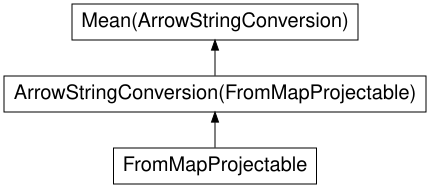

In [6]:
mean_values_dask.visualize()

### Computing and Printing Mean Values

The next cell computes the mean values of all columns in the Dask dataframe `df_dask` by executing the task graph created earlier. The `compute()` method triggers the actual computation and retrieves the results. The computed mean values are then printed to the output, providing a summary of the dataset's average values.

In [7]:
print(mean_values_dask.compute())

col0   -0.000031
col1   -0.000421
col2   -0.000426
col3    0.000366
col4   -0.000508
col5    0.000395
col6   -0.000061
col7    0.000142
col8    0.000061
col9   -0.000261
dtype: float64


### Sorting the Dask Dataframe

The next cell sorts the Dask dataframe `df_dask` by the column `col0` and stores the result in the variable `df_sorted`. Sorting is performed lazily, meaning the operation creates a task graph but does not execute immediately. 

In [9]:
df_sorted = df_dask.sort_values("col0")


### Triggering Computation by Viewing Data

The next cell triggers the computation of the task graph created for sorting the Dask dataframe `df_sorted`. When we request to display the first 20 rows of the dataframe using the `head()` method, Dask executes the necessary computations to produce the requested data. This lazy evaluation ensures that only the required tasks are performed, optimizing resource usage and efficiency.
```

In [10]:
df_sorted.head(20)

,col0,col1,col2,col3,col4,col5,col6,col7,col8,col9
112855,-5.377438,-0.803459,-1.096144,-0.810401,-1.585620,0.354008,1.453681,0.031542,0.877614,1.406464
238427,-5.289905,1.725364,-1.295239,0.708638,-0.041937,-0.741380,-1.553733,1.572337,-1.465904,-0.741528
49272,-5.240848,0.029609,1.707762,-0.541172,-1.289393,-0.014985,-0.902013,1.224783,0.078924,0.142122
1943,-5.154258,-0.865238,0.724476,0.102958,0.613587,-2.733850,0.291936,-0.414777,-0.068574,-0.820831
302442,-5.127437,-1.410443,0.319297,-0.611506,-1.827095,-0.185125,1.507453,0.933623,0.616932,0.408307
314986,-5.028395,0.948998,0.887262,0.760653,0.572315,0.717055,2.321790,-0.368189,-0.473291,-1.329799
148443,-4.903020,2.407530,1.753680,1.825505,0.470263,-0.149462,-2.171305,-0.698122,-0.278330,0.715866
84935,-4.849311,-0.725743,-1.148779,-0.987837,0.038613,1.011676,-0.990097,-1.594799,-0.012435,-0.185950
276899,-4.828190,-0.984352,1.935880,0.881269,0.975654,-1.115101,-0.267588,-0.199570,0.539613,-0.341845
208125,-4.826326,1.747460,-0.501419,-1.072053,0.291646,1.879420,-2.256272,0.424059,-0.053163,-2.060172


### Computing and Plotting a Histogram

In the following cells, we will compute and plot a histogram for one of the columns in the Dask dataframe `df_dask`. This involves calculating the range of values, creating a histogram using Dask arrays, and visualizing the results with Matplotlib. This process demonstrates how to efficiently analyze and visualize large datasets using Dask's parallel computing capabilities.


In [11]:
%pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Computing the Range of a Column

The next cell computes the range (minimum and maximum values) of the column `col0` in the Dask dataframe `df_dask`. The `min()` and `max()` operations are performed lazily, creating a task graph. The `dask.compute()` function is then used to execute these operations in parallel and retrieve the results. The computed range is stored as a list and printed to the output, providing insight into the value distribution of the selected column.

In [12]:
import dask

# Select a column to compute a histogram
col_name = 'col0'

# compute the range of that column
range = [
    df_dask[col_name].min(),
    df_dask[col_name].max(),
]

# compute both operations at once
range = dask.compute(*range)
range = list(range)
range

[np.float64(-5.377437651915645), np.float64(5.257634559601616)]

### Creating a Dask Array and Computing a Histogram

The next cell converts the selected column `col0` of the Dask dataframe `df_dask` into a Dask array using the `to_dask_array` method. This allows for efficient numerical computations on the column's data. A histogram is then computed using the `da.histogram` function, which divides the data into 50 bins within the specified range. The resulting histogram data (`hist`) and bin edges (`bin_edges`) are stored for further analysis and visualization.

By using a Dask array, we can perform the calculations in a distributed workflow, leveraging parallelism to handle large datasets efficiently. This approach ensures that computations are scalable and optimized for performance across multiple workers.

In [13]:
import dask.array as da

dask_array = df_dask[col_name].to_dask_array(lengths=True)

# Compute the histogram using Dask array
hist, bin_edges = da.histogram(dask_array, bins=50, range=range)

### Computing the Histogram

The histogram for the selected column `col0` has been defined but not yet computed. The computation will be triggered in the subsequent cells, where the histogram data will be processed and visualized. This step ensures that the task graph for the histogram calculation is executed, providing the necessary data for further analysis and plotting.

In [14]:
print(bin_edges)
print(hist)

[-5.37743765 -5.16473621 -4.95203476 -4.73933332 -4.52663187 -4.31393043
 -4.10122899 -3.88852754 -3.6758261  -3.46312465 -3.25042321 -3.03772177
 -2.82502032 -2.61231888 -2.39961743 -2.18691599 -1.97421454 -1.7615131
 -1.54881166 -1.33611021 -1.12340877 -0.91070732 -0.69800588 -0.48530443
 -0.27260299 -0.05990155  0.1527999   0.36550134  0.57820279  0.79090423
  1.00360567  1.21630712  1.42900856  1.64171001  1.85441145  2.0671129
  2.27981434  2.49251578  2.70521723  2.91791867  3.13062012  3.34332156
  3.55602301  3.76872445  3.98142589  4.19412734  4.40682878  4.61953023
  4.83223167  5.04493312  5.25763456]
dask.array<sum-aggregate, shape=(50,), dtype=int64, chunksize=(50,), chunktype=numpy.ndarray>


### Plotting the Computed Histogram

With the histogram data computed, we can now visualize it using Matplotlib. The histogram plot will provide a graphical representation of the frequency distribution of values in the selected column `col0`, offering insights into the data's underlying patterns and trends.

In [15]:
hist = hist.compute()
print(hist)

[     3      3      5     26     51    110    312    688   1454   3095
   6239  11704  21244  36929  61752  98467 148376 216362 300630 398013
 506662 613577 712491 788627 834329 846070 818373 759393 669916 567217
 458637 354774 260793 184646 125020  80740  49759  29481  16549   8897
   4466   2250   1073    447    205     90     34     16      3      2]


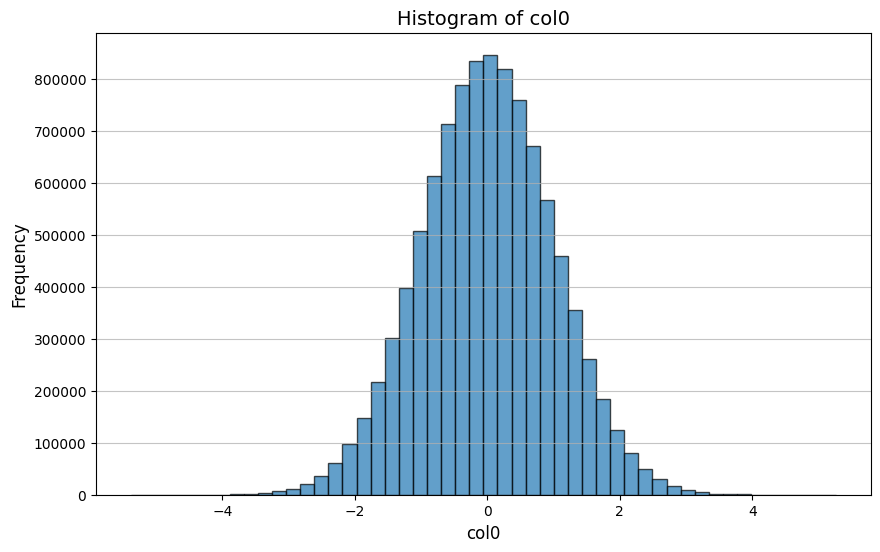

In [16]:
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(10, 6))
plt.hist(bin_edges[:-1], bins=bin_edges, weights=hist, edgecolor='k', alpha=0.7)
plt.title(f'Histogram of {col_name}', fontsize=14)
plt.xlabel(col_name, fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

### Shutting Down the Dask Cluster

The next cell shuts down the Dask cluster by closing it, which terminates all worker jobs associated with the cluster. This ensures that no worker jobs remain running, freeing up resources. Additionally, the status of the jobs can be verified to confirm that they have been successfully terminated.

In [17]:
cluster.close()

In [18]:
!qstat -u akuehlka